# Q learning

Début de l'entraînement...
Evaluation: Mean Reward = -20642.40 +- 0.00
Evaluation: Mean Reward = -20642.40 +- 0.00


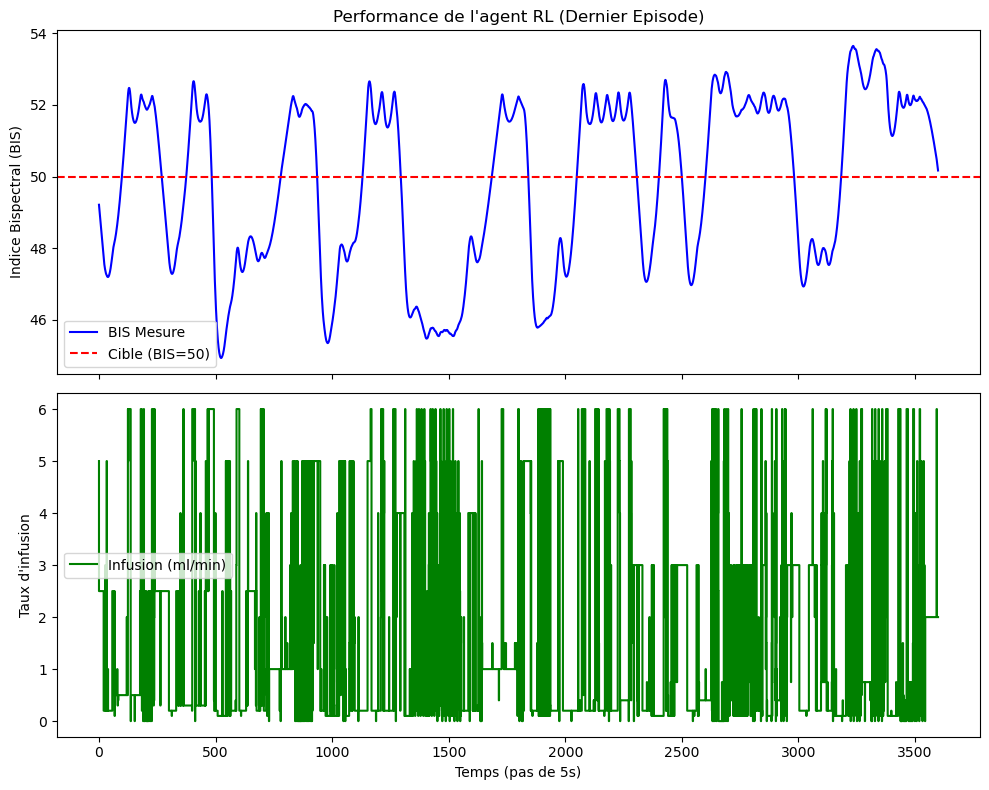

In [ ]:
import numpy as np
import pandas as pd
import random
from pathlib import Path

from utils.rl_visualization import plot_simple_episode
from utils.eval_metrics import (
    calculate_bis_metrics,
    get_age_group,
    create_results_dataframe,
    create_summary_by_age_group,
    save_evaluation_results,
)

# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================

TARGET_BIS = 50.0
EPISODES = 5000
STEPS_PER_EPISODE = 3600
ALPHA = 0.2
GAMMA = 0.69
EPSILON = 0.05

# ============================================================================
# PK/PD PARAMETERS (Schnider Model)
# ============================================================================

V1, V2, V3 = 4.27, 18.9, 238.0
k10, k12, k21, k13, k31 = 0.38, 0.30, 0.20, 0.19, 0.0035
ke0 = 0.17
BIS_0, BIS_MAX, EC50, HILL = 95.0, 75.0, 3.5, 2.5

# ============================================================================
# RL CONFIGURATION
# ============================================================================

ACTIONS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0]

# ============================================================================
# EVALUATION CONFIGURATION
# ============================================================================

EVAL_SAMPLE_SIZE = 500
EVAL_EPISODE_LENGTHS = [300, 600, 1200, 3600]
EVAL_TIME_STEP = 5 / 60
RANDOM_SEED = 42

AGE_GROUPS = {
    "25-29": (25, 29),
    "30-45": (30, 45),
    "46-60": (46, 60),
    "60-80": (60, 80),
    "80+": (80, 120),
}

# ============================================================================
# PATHS
# ============================================================================

ARTIFACTS_DIR = Path("artifacts")
METRICS_DIR = Path("metrics")
DATA_PATH = Path("data/Patients Data.csv")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

Q_PATH = ARTIFACTS_DIR / "q_agent_error_delta.npz"

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

class AnesthesiaEnv:
    def __init__(self, target_bis=TARGET_BIS):
        self.state_pk = np.zeros(3)
        self.ce = 0.0
        self.target = target_bis
        self.dt = 5 / 60

    def step(self, action_idx):
        u = ACTIONS[action_idx]
        c0, c1, c2 = self.state_pk[0], self.state_pk[1], self.state_pk[2]

        dc0 = (u - (k10 + k12 + k13) * c0 + k21 * c1 + k31 * c2) / V1
        dc1 = k12 * c0 - k21 * c1
        dc2 = k13 * c0 - k31 * c2

        self.state_pk[0] = c0 + dc0 * self.dt
        self.state_pk[1] = c1 + dc1 * self.dt
        self.state_pk[2] = c2 + dc2 * self.dt

        self.ce += ke0 * (self.state_pk[0] - self.ce) * self.dt

        bis = BIS_0 - BIS_MAX * (self.ce**HILL / (self.ce**HILL + EC50**HILL))
        error = bis - self.target
        reward = -abs(error)
        return bis, error, reward


def get_fuzzy_features(val, scale):
    """Return [negative, zero, positive] memberships for val."""
    v = np.clip(val / scale, -1, 1)
    mu_n = max(0.0, -v)
    mu_p = max(0.0, v)
    mu_z = max(0.0, 1.0 - abs(v))
    return [mu_n, mu_z, mu_p]


def get_state_index(error, delta_error):
    """Map 6D fuzzy vector (error + delta_error) to a discrete state index."""
    f = get_fuzzy_features(error, 20) + get_fuzzy_features(delta_error, 10)
    bins = [int(min(val * 9, 9)) for val in f]
    idx = 0
    for b in bins:
        idx = idx * 10 + b
    return idx


def load_data(path):
    return pd.read_csv(path)


def preprocess_data(df):
    df = df.copy()

    def parse_age(x):
        try:
            parts = str(x).strip().split(" ")
            if len(parts) < 2:
                return 50
            low = int(parts[1])
            if len(parts) > 3:
                high = 100 if parts[3] == "older" else int(parts[3])
                return int(random.randrange(low, high))
            return int(low)
        except Exception:
            return 50

    if "AgeCategory" in df.columns:
        df.loc[:, "AgeCategory"] = df["AgeCategory"].apply(parse_age)
    return df


def schnider_model(age, weight, height, sex):
    sex = str(sex).lower()
    if sex == "male":
        lbm = 1.10 * weight - 128 * (weight**2) / (height**2)
    else:
        lbm = 1.07 * weight - 148 * (weight**2) / (height**2)

    V1_s = 4.27
    V2_s = 18.9 - 0.391 * (age - 53)
    k10_s = 0.443 + 0.0107 * (weight - 77) - 0.0159 * (lbm - 59) + 0.0062 * (height - 177)
    k12_s = 0.302 - 0.0056 * (age - 53)
    k13_s = 0.196
    k21_s = (1.29 - 0.024 * (age - 53)) / V2_s
    k31_s = 0.0035
    ke0_s = 0.456

    A = np.array(
        [
            [-(k10_s + k12_s + k13_s), k21_s, k31_s, 0],
            [k12_s, -k21_s, 0, 0],
            [k13_s, 0, -k31_s, 0],
            [ke0_s, 0, 0, -ke0_s],
        ],
        dtype=float,
    )
    B = np.array([[1 / V1_s], [0], [0], [0]], dtype=float)
    return {"A": A, "B": B}


def generate_schnider_dataset(df):
    params_list = []
    for _, row in df.iterrows():
        params = schnider_model(
            age=row["AgeCategory"],
            weight=row["WeightInKilograms"],
            height=row["HeightInMeters"],
            sex=row["Sex"],
        )
        params_list.append(params)

    params_df = pd.DataFrame(params_list)
    return pd.concat([df.reset_index(drop=True), params_df], axis=1)


class QLearningEvaluator:
    def __init__(self, q_table, actions):
        self.Q = q_table
        self.actions = actions
        self.target = TARGET_BIS
        self.bis0 = BIS_0
        self.bis_max = BIS_MAX
        self.ec50 = EC50
        self.hill = HILL

    def _get_state_idx(self, error, delta):
        error = np.clip(float(error), -50.0, 50.0) if np.isfinite(error) else 0.0
        delta = np.clip(float(delta), -30.0, 30.0) if np.isfinite(delta) else 0.0
        f1 = np.clip((error + 20) / 40, 0, 0.99)
        f2 = np.clip((delta + 10) / 20, 0, 0.99)
        idx = int(np.clip(f1 * 10, 0, 9)) * 10 + int(np.clip(f2 * 10, 0, 9))
        return idx

    def simulate(self, patient_row, duration_seconds):
        duration_steps = int(duration_seconds / 5)
        A = np.asarray(patient_row["A"], dtype=float)
        B = np.asarray(patient_row["B"], dtype=float)
        x = np.zeros((4, 1), dtype=float)

        bis_log = []
        prev_error = 0.0

        for _ in range(duration_steps):
            ce = np.clip(float(x[3, 0]), 0.0, 10.0)
            if not np.isfinite(ce):
                ce = 0.0
                x = np.zeros((4, 1), dtype=float)

            ce_h = np.power(ce, self.hill)
            ec50_h = np.power(self.ec50, self.hill)

            if ec50_h + ce_h > 0:
                bis_ideal = self.bis0 - self.bis_max * (ce_h / (ec50_h + ce_h))
            else:
                bis_ideal = self.bis0

            bis_ideal = np.clip(float(bis_ideal), 0, 100) if np.isfinite(bis_ideal) else self.bis0
            measured_bis = np.clip(bis_ideal + np.random.normal(0, 3), 0, 100)

            error = np.clip(float(measured_bis - self.target), -50.0, 50.0)
            delta = np.clip(float(error - prev_error), -30.0, 30.0)

            s_idx = self._get_state_idx(error, delta)
            a_idx = int(np.argmax(self.Q[s_idx]))
            u = float(self.actions[a_idx])

            x_dot = A @ x + B * u
            x = x + x_dot * EVAL_TIME_STEP
            x = np.clip(x, -10.0, 10.0)

            bis_log.append(float(measured_bis))
            prev_error = error

        return np.array(bis_log)

# ============================================================================
# TRAINING SECTION
# ============================================================================

env = AnesthesiaEnv()
Q = np.zeros((100, len(ACTIONS)))
history_bis = []
history_actions = []

print("=" * 70)
print("Q-LEARNING TRAINING: Error + Delta Feature Representation")
print("=" * 70)

for ep in range(EPISODES):
    env = AnesthesiaEnv(target_bis=TARGET_BIS)
    bis, error, _ = env.step(0)
    prev_error = error
    s = get_state_index(error, 0.0)

    for _ in range(STEPS_PER_EPISODE):
        if np.random.rand() < EPSILON:
            a = np.random.randint(len(ACTIONS))
        else:
            a = int(np.argmax(Q[s]))

        bis, next_error, r = env.step(a)
        s_next = get_state_index(next_error, next_error - error)

        Q[s, a] = Q[s, a] + ALPHA * (r + GAMMA * np.max(Q[s_next]) - Q[s, a])

        if ep == EPISODES - 1:
            history_bis.append(bis)
            history_actions.append(ACTIONS[a])

        prev_error = error
        error = next_error
        s = s_next

    if (ep + 1) % 500 == 0:
        print(f"  Episode {ep + 1}/{EPISODES} completed")

np.savez_compressed(
    Q_PATH,
    Q=Q,
    actions=np.array(ACTIONS, dtype=float),
    target_bis=np.array([TARGET_BIS], dtype=float),
    alpha=np.array([ALPHA], dtype=float),
    gamma=np.array([GAMMA], dtype=float),
    epsilon=np.array([EPSILON], dtype=float),
)
print(f"\nSaved Q-table to {Q_PATH}")

# ============================================================================
# VISUALIZATION
# ============================================================================

plot_simple_episode(history_bis, history_actions, target=TARGET_BIS)

# ============================================================================
# EVALUATION SECTION (STANDARDIZED)
# ============================================================================

print("\n" + "=" * 70)
print("EVALUATION ON POPULATION DATASET")
print("=" * 70)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"\n1. Loading patient data from {DATA_PATH}...")
df = load_data(DATA_PATH)
df = preprocess_data(df)
print(f"   Loaded {len(df)} patients")

print(f"\n2. Sampling {EVAL_SAMPLE_SIZE} patients...")
sample_df = df.sample(n=min(EVAL_SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED)
print(f"   Sampled {len(sample_df)} patients")

print("\n3. Generating Schnider PK/PD parameters...")
eval_df = generate_schnider_dataset(sample_df)
print(f"   Generated parameters for {len(eval_df)} patients")

print(f"\n4. Loading trained Q-learning agent from {Q_PATH}...")
q_data = np.load(Q_PATH)
Q_eval = q_data["Q"]
actions_eval = q_data["actions"]
print(f"   Loaded Q table: shape {Q_eval.shape}")

evaluator = QLearningEvaluator(Q_eval, actions_eval)

print(f"\n5. Evaluating policy at {len(EVAL_EPISODE_LENGTHS)} episode lengths...")
patient_results = []

for idx, (_, patient) in enumerate(eval_df.iterrows()):
    if (idx + 1) % 50 == 0:
        print(f"   Processing patient {idx + 1}/{len(eval_df)}...")

    patient_id = patient["PatientID"]
    age = patient["AgeCategory"]
    age_group = get_age_group(age, AGE_GROUPS)

    results = {}
    for ep_len in EVAL_EPISODE_LENGTHS:
        bis_traj = evaluator.simulate(patient, ep_len)
        metrics = calculate_bis_metrics(bis_traj, TARGET_BIS)
        results[ep_len] = metrics

    patient_results.append(
        {
            "patient_id": patient_id,
            "age": age,
            "age_group": age_group,
            "results": results,
        }
    )

results_df = create_results_dataframe(patient_results, EVAL_EPISODE_LENGTHS)
summary_df = create_summary_by_age_group(results_df, EVAL_EPISODE_LENGTHS, AGE_GROUPS)

print("\n6. Saving evaluation results...")
save_evaluation_results(
    results_df,
    summary_df,
    "q_agent_error_delta",
    str(METRICS_DIR),
)

print("\n" + "=" * 70)
print("Evaluation complete!")
print(f"  - Results: {len(results_df)} patients")
print(f"  - Age groups: {results_df['AgeGroup'].nunique()}")
print(f"  - Episode lengths: {len(EVAL_EPISODE_LENGTHS)}")
print("=" * 70)